# Entailment cones

In [2]:
import torch
import numpy as np
import geoopt
import torch.nn.functional as F

In [3]:
# Curvature of the hyperboloid
k=torch.tensor([4.0])

# 8 points correspoinding to the space dimensions in 2D
x = torch.randn(8, 2)

# Adding 0's to first dimension to compute exponential map at origin
x_padded = F.pad(x, (1,0,0,0))

# Points on the hyperboloid
x_hyp = geoopt.manifolds.lorentz.math.expmap0(x_padded, k=k)

In [4]:
# Compute half apertures
half_apertures = geoopt.manifolds.lorentz.math.half_aperture(x_hyp, k)

### Visualization

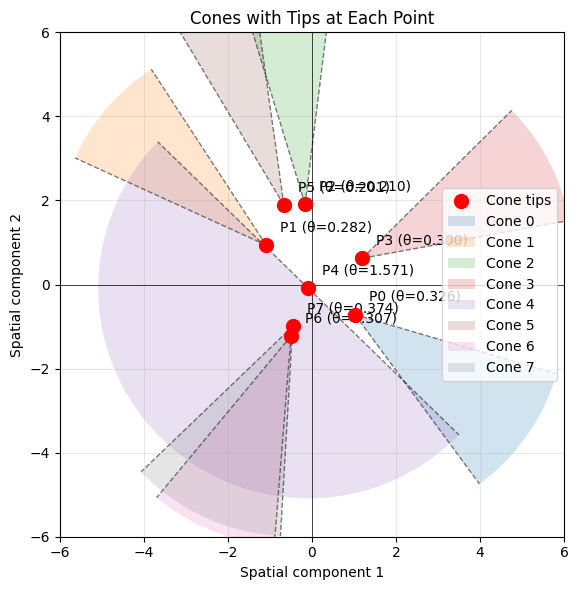

In [5]:
from matplotlib import pyplot as plt

# Create figure
fig, ax = plt.subplots(figsize=(6, 6))

points = x_hyp.narrow(-1,1,2)

# Plot the points
x = points[:, 0].numpy()
y = points[:, 1].numpy()
ax.scatter(x, y, s=100, c='red', zorder=5, label='Cone tips')

# For each point, draw the cone
for i, (point, half_angle) in enumerate(zip(points, half_apertures)):
    # Direction from origin to point (this is the direction the cone opens)
    direction = point / torch.norm(point)
    
    # Angle of the central direction
    central_angle = torch.atan2(point[1], point[0])
    
    # Cone boundaries
    angle1 = central_angle - half_angle
    angle2 = central_angle + half_angle
    
    # Create the cone visualization
    # The cone starts at the point and extends outward
    extension_length = 5  # How far the cone extends from the tip
    
    # Generate the cone shape
    theta = torch.linspace(angle1, angle2, 50)
    
    # Draw filled cone
    vertices = [[point[0].item(), point[1].item()]]  # Start at the point (tip)
    for t in theta:
        # Extend from the point outward
        end_x = point[0].item() + extension_length * torch.cos(t).item()
        end_y = point[1].item() + extension_length * torch.sin(t).item()
        vertices.append([end_x, end_y])
    vertices.append([point[0].item(), point[1].item()])  # Close at tip
    
    vertices = np.array(vertices)
    ax.fill(vertices[:, 0], vertices[:, 1], alpha=0.2, label=f'Cone {i}')
    
    # Draw cone edges
    ax.plot([point[0].item(), point[0].item() + extension_length * np.cos(angle1.item())], 
            [point[1].item(), point[1].item() + extension_length * np.sin(angle1.item())], 
            'k--', linewidth=1, alpha=0.5)
    ax.plot([point[0].item(), point[0].item() + extension_length * np.cos(angle2.item())], 
            [point[1].item(), point[1].item() + extension_length * np.sin(angle2.item())], 
            'k--', linewidth=1, alpha=0.5)
    
    # Annotate the point
    ax.annotate(f'P{i} (θ={half_angle.item():.3f})', 
                (point[0].item(), point[1].item()),
                xytext=(10, 10), textcoords='offset points')

# Formatting
ax.set_xlabel('Spatial component 1')
ax.set_ylabel('Spatial component 2')
ax.set_title('Cones with Tips at Each Point')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)
ax.set_aspect('equal')
ax.legend()
ax.set_xlim(-6, 6)
ax.set_ylim(-6, 6)

plt.tight_layout()
plt.show()

Spatial components of point in tangent space: tensor([[-1.1083, -0.4231]])
Shape: torch.Size([1, 2])

Operations with geoopt implementation   
Point in the tangent space: tensor([[ 0.0000, -1.1083, -0.4231]])
Shape: torch.Size([1, 3])
Curvature k: tensor([1.])
Point in the hyperboloid: tensor([[ 1.7902, -1.3872, -0.5296]])
Shape: torch.Size([1, 3])
Half apertures: tensor([0.1694])

Space coordinates after geoopt logmap0: tensor([-1.1083, -0.4231])
Input point tensor: tensor([-1.1083, -0.4231])
Both points should match, since input tensor is in tangent space and we are mapping back from hyperboloid to tangent space.



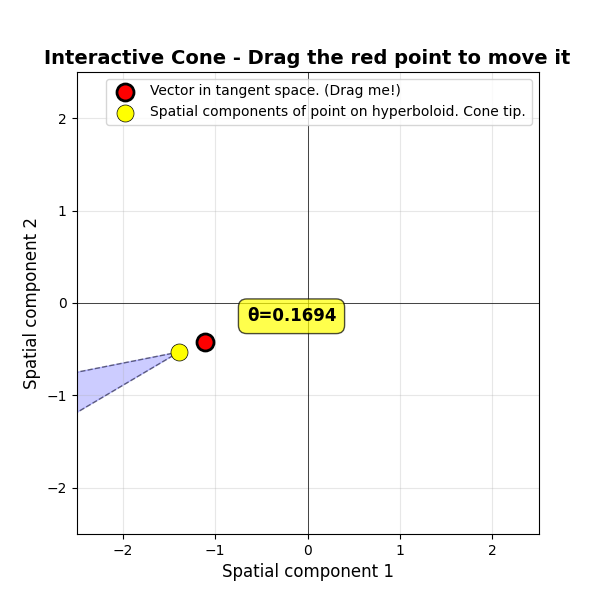

In [6]:
%matplotlib ipympl
import matplotlib.pyplot as plt
import torch
import numpy as np
import torch.nn.functional as F

import math

class DraggableCone:
    def __init__(self, initial_x=-1.1083, initial_y=-0.4231):
        self.point = [initial_x, initial_y]
        self.dragging = False
        self.k = torch.tensor([1.0])
        
        # Create figure and axis
        self.fig, self.ax = plt.subplots(figsize=(6, 6))
        
        # Initial plot
        self.update_plot()
        
        # Connect events
        self.fig.canvas.mpl_connect('button_press_event', self.on_press)
        self.fig.canvas.mpl_connect('button_release_event', self.on_release)
        self.fig.canvas.mpl_connect('motion_notify_event', self.on_motion)
        
        plt.show()
    
    def update_plot(self):
        self.ax.clear()
        
        # Create tensor and compute half aperture
        points = torch.tensor([self.point])
        print(f"Spatial components of point in tangent space: {points}")
        print(f"Shape: {points.shape}")
        print()
        x_points = F.pad(points,(1,0,0,0))
        print("Operations with geoopt implementation   ")
        print(f"Point in the tangent space: {x_points}")
        print(f"Shape: {x_points.shape}")
        print(f"Curvature k: {self.k}")
        ex_points = geoopt.manifolds.lorentz.math.expmap0(x_points, k=self.k)
        half_apertures = geoopt.manifolds.lorentz.math.half_aperture(x_points, self.k)
        print(f"Point in the hyperboloid: {ex_points}")
        print(f"Shape: {ex_points.shape}")
        print(f"Half apertures: {half_apertures}")
        print()

        # Draw the cone
        ex_point = ex_points[0][1:]  # Space components
        lx_point = geoopt.manifolds.lorentz.math.logmap0(ex_points, k=self.k)[0][1:]  # Space components at tangent space, should match with input
        print(f"Space coordinates after geoopt logmap0: {lx_point}")
        print(f"Input point tensor: {points[0]}")
        print("Both points should match, since input tensor is in tangent space and we are mapping back from hyperboloid to tangent space.")
        print()

        
        # Plot the point
        self.ax.scatter(self.point[0], self.point[1], s=150, c='red', 
                       zorder=5, label='Vector in tangent space. (Drag me!)', edgecolors='black', linewidths=2)
        self.ax.scatter(ex_point[0].item(), ex_point[1].item(), s=150, c='yellow', 
                       zorder=5, label='Spatial components of point on hyperboloid. Cone tip.', edgecolors='black', linewidths=0.5)

        half_angle = half_apertures[0]

        # Central angle
        central_angle = torch.atan2(lx_point[1], lx_point[0])
        e_central_angle = torch.atan2(ex_point[1], ex_point[0])

        # Cone boundaries
        angle1 = central_angle - half_angle
        angle2 = central_angle + half_angle
        
        # Extension length
        extension_length = 5
        
        # Generate the cone shape
        theta = torch.linspace(angle1, angle2, 50)
        
        # Draw filled cone
        vertices = [[ex_point[0].item(), ex_point[1].item()]]
        for t in theta:
            end_x = ex_point[0].item() + extension_length * torch.cos(t).item()
            end_y = ex_point[1].item() + extension_length * torch.sin(t).item()
            vertices.append([end_x, end_y])
        vertices.append([ex_point[0].item(), ex_point[1].item()])

        vertices = np.array(vertices)
        self.ax.fill(vertices[:, 0], vertices[:, 1], alpha=0.2, color='blue')
        
        # Draw cone edges
        self.ax.plot([ex_point[0].item(), ex_point[0].item() + extension_length * np.cos(angle1.item())], 
                [ex_point[1].item(), ex_point[1].item() + extension_length * np.sin(angle1.item())], 
                'k--', linewidth=1, alpha=0.5)
        self.ax.plot([ex_point[0].item(), ex_point[0].item() + extension_length * np.cos(angle2.item())], 
                [ex_point[1].item(), ex_point[1].item() + extension_length * np.sin(angle2.item())], 
                'k--', linewidth=1, alpha=0.5)
        
        # Annotate
        self.ax.annotate(f'θ={half_angle.item():.4f}', 
                    (lx_point[0].item(), lx_point[1].item()),
                    xytext=(30, 15), textcoords='offset points',
                    fontsize=12, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

        # Formatting
        self.ax.set_xlabel('Spatial component 1', fontsize=12)
        self.ax.set_ylabel('Spatial component 2', fontsize=12)
        self.ax.set_title('Interactive Cone - Drag the red point to move it', fontsize=14, fontweight='bold')
        self.ax.grid(True, alpha=0.3)
        self.ax.axhline(y=0, color='k', linewidth=0.5)
        self.ax.axvline(x=0, color='k', linewidth=0.5)
        self.ax.set_aspect('equal')
        self.ax.legend(fontsize=10)
        self.ax.set_xlim(-2.5, 2.5)
        self.ax.set_ylim(-2.5, 2.5)

        self.fig.canvas.draw_idle()
    
    def on_press(self, event):
        if event.inaxes != self.ax:
            return
        
        # Check if click is near the point
        dx = event.xdata - self.point[0]
        dy = event.ydata - self.point[1]
        distance = np.sqrt(dx**2 + dy**2)
        
        # If click is within 0.15 units of the point, start dragging
        if distance < 0.15:
            self.dragging = True
    
    def on_release(self, event):
        self.dragging = False
    
    def on_motion(self, event):
        if not self.dragging or event.inaxes != self.ax:
            return
        
        # Update point position
        self.point[0] = event.xdata
        self.point[1] = event.ydata
        
        # Redraw
        self.update_plot()

# Create the interactive plot
draggable = DraggableCone(initial_x=-1.1083, initial_y=-0.4231)

## Exterior Angle in Hyperbolic Triangles
Create a hyperbolic triangle formed by the origin and two points, and compute the exterior angle.

In [7]:
# Create two points in 2D space
x = torch.tensor([[1.0, 0.5]])
y = torch.tensor([[0.5, 1.5]])

# Adding 0's to first dimension to compute exponential map at origin
x_padded = F.pad(x, (1, 0, 0, 0))  # Shape: (1, 3)
y_padded = F.pad(y, (1, 0, 0, 0))  # Shape: (1, 3)

# Curvature of the hyperboloid
k = torch.tensor([1.0])

# Points on the hyperboloid
x_hyp = geoopt.manifolds.lorentz.math.expmap0(x_padded, k=k)
y_hyp = geoopt.manifolds.lorentz.math.expmap0(y_padded, k=k)

print(f"Point x on hyperboloid: {x_hyp}")
print(f"Point y on hyperboloid: {y_hyp}")

Point x on hyperboloid: tensor([[1.6929, 1.2217, 0.6109]])
Point y on hyperboloid: tensor([[2.5331, 0.7360, 2.2079]])


In [8]:
# Compute exterior angle
ext_angle = geoopt.manifolds.lorentz.math.exterior_angle(x_hyp, y_hyp, k)
print(f"Exterior angle (radians): {ext_angle.item():.4f}")
print(f"Exterior angle (degrees): {torch.rad2deg(ext_angle).item():.4f}°")

Exterior angle (radians): 1.9596
Exterior angle (degrees): 112.2761°


External Angle and Cone Aperture with Draggable Points

Updating plot...
Point 1: (-0.6083, 0.0769)
Point 2: (-1.6500, -0.6900)

Half aperture (geoopt): 0.4636
Exterior angle (geoopt): 0.8649

Half angle: 0.4636
Exterior angle: 0.8649
Entailment loss (clamped ext - half): 0.4013



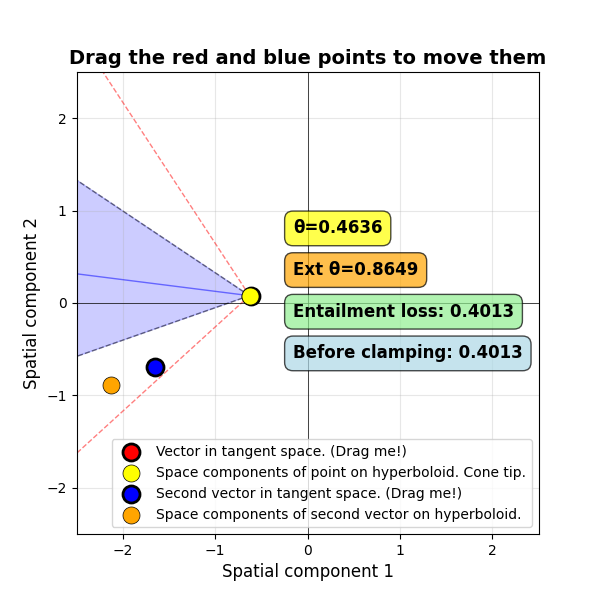

In [9]:
%matplotlib ipympl
import matplotlib.pyplot as plt
import torch
import numpy as np
import torch.nn.functional as F

import math

class DraggableCone:
    def __init__(self, initial_x=-1.1083, initial_y=-0.4231):
        self.point1 = [initial_x+ 0.5, initial_y + 0.5]
        self.point2 = [-1.65, -0.69]
        self.dragging1 = False
        self.dragging2 = False
        self.k = torch.tensor([2.0])
        
        # Create figure and axis
        self.fig, self.ax = plt.subplots(figsize=(6, 6))
        
        # Initial plot
        self.update_plot()
        
        # Connect events
        self.fig.canvas.mpl_connect('button_press_event', self.on_press)
        self.fig.canvas.mpl_connect('button_release_event', self.on_release)
        self.fig.canvas.mpl_connect('motion_notify_event', self.on_motion)
        
        plt.show()
    
    def update_plot(self):
        self.ax.clear()

        print("Updating plot...")
        print(f"Point 1: ({self.point1[0]:.4f}, {self.point1[1]:.4f})")
        print(f"Point 2: ({self.point2[0]:.4f}, {self.point2[1]:.4f})")
        print()
        
        # Create tensor and compute half aperture
        point1 = torch.tensor([self.point1])
        point2 = torch.tensor([self.point2])
        x_point1 = F.pad(point1, (1, 0, 0, 0))
        x_point2 = F.pad(point2, (1, 0, 0, 0))


        ex_point1 = geoopt.manifolds.lorentz.math.expmap0(x_point1, k=self.k)
        ex_point2 = geoopt.manifolds.lorentz.math.expmap0(x_point2, k=self.k)

        half_aperture = geoopt.manifolds.lorentz.math.half_aperture(ex_point1, self.k)
        ext_angle = geoopt.manifolds.lorentz.math.exterior_angle(ex_point1, ex_point2, self.k)

        ex_point1 = ex_point1[0][1:]  # Space components
        ex_point2 = ex_point2[0][1:]  # Space components

        print(f"Half aperture (geoopt): {half_aperture.item():.4f}")
        print(f"Exterior angle (geoopt): {ext_angle.item():.4f}")
        print()

        # Plot the point
        self.ax.scatter(point1[0][0], point1[0][1], s=150, c='red', 
                       zorder=5, label='Vector in tangent space. (Drag me!)', edgecolors='black', linewidths=2)
        self.ax.scatter(ex_point1[0], ex_point1[1], s=150, c='yellow', 
                       zorder=5, label='Space components of point on hyperboloid. Cone tip.', edgecolors='black', linewidths=0.5)
        self.ax.scatter(point2[0][0], point2[0][1], s=150, c='blue', 
                       zorder=5, label='Second vector in tangent space. (Drag me!)', edgecolors='black', linewidths=2)
        self.ax.scatter(ex_point2[0], ex_point2[1], s=150, c='orange', 
                       zorder=5, label='Space components of second vector on hyperboloid.', edgecolors='black', linewidths=0.5)

        half_angle = half_aperture[0]
        print(f"Half angle: {half_angle.item():.4f}")
        ext_angle = ext_angle[0]
        print(f"Exterior angle: {ext_angle.item():.4f}")
        ent_loss = torch.clamp(ext_angle - half_angle, min=0).mean()
        diff = (ext_angle - half_angle).mean()
        print(f"Entailment loss (clamped ext - half): {ent_loss.item():.4f}")
        print()


        # Central angle
        central_angle = torch.atan2(point1[0][1], point1[0][0])

        # Cone boundaries
        angle1 = central_angle - half_angle
        angle2 = central_angle + half_angle

        # External angle
        angle3 = central_angle - ext_angle
        angle4 = central_angle + ext_angle
        
        # Extension length
        extension_length = 17.5
        
        # Generate the cone shape
        theta = torch.linspace(angle1, angle2, 50)
        
        # Draw filled cone
        #vertices = [[tip_cone_hyp[1].item(), tip_cone_hyp[2].item()]]
        vertices = [[ex_point1[0].item(), ex_point1[1].item()]]
        for t in theta:
            end_x = ex_point1[0].item() + extension_length * torch.cos(t).item()
            end_y = ex_point1[1].item() + extension_length * torch.sin(t).item()
            vertices.append([end_x, end_y])
        vertices.append([ex_point1[0].item(), ex_point1[1].item()])

        vertices = np.array(vertices)
        self.ax.fill(vertices[:, 0], vertices[:, 1], alpha=0.2, color='blue')
        
        # Draw cone edges
        self.ax.plot([ex_point1[0].item(), ex_point1[0].item() + extension_length * np.cos(angle1.item())], 
                [ex_point1[1].item(), ex_point1[1].item() + extension_length * np.sin(angle1.item())], 
                'k--', linewidth=1, alpha=0.5)
        self.ax.plot([ex_point1[0].item(), ex_point1[0].item() + extension_length * np.cos(angle2.item())], 
                [ex_point1[1].item(), ex_point1[1].item() + extension_length * np.sin(angle2.item())], 
                'k--', linewidth=1, alpha=0.5)
        
        # Draw external angle edge
        self.ax.plot([ex_point1[0].item(), ex_point1[0].item() + extension_length * np.cos(angle3.item())], 
                [ex_point1[1].item(), ex_point1[1].item() + extension_length * np.sin(angle3.item())], 
                'r--', linewidth=1, alpha=0.5)
        self.ax.plot([ex_point1[0].item(), ex_point1[0].item() + extension_length * np.cos(angle4.item())], 
                [ex_point1[1].item(), ex_point1[1].item() + extension_length * np.sin(angle4.item())], 
                'r--', linewidth=1, alpha=0.5)

        # Reference angle
        self.ax.plot([ex_point1[0].item(), ex_point1[0].item() + extension_length * np.cos(central_angle.item())], 
                [ex_point1[1].item(), ex_point1[1].item() + extension_length * np.sin(central_angle.item())], 
                'b', linewidth=1, alpha=0.5)
        
        # Annotate
        self.ax.annotate(f'θ={half_angle.item():.4f}', 
                    (point1[0][0].item(), point1[0][1].item()),
                    xytext=(30, 45), textcoords='offset points',
                    fontsize=12, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))
        self.ax.annotate(f'Ext θ={ext_angle.item():.4f}', 
                    (point1[0][0].item(), point1[0][1].item()),
                    xytext=(30, 15), textcoords='offset points',
                    fontsize=12, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.5', facecolor='orange', alpha=0.7))
        self.ax.annotate(f'Entailment loss: {ent_loss.item():.4f}', 
                    (point1[0][0].item(), point1[0][1].item()),
                    xytext=(30, -15), textcoords='offset points',
                    fontsize=12, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', alpha=0.7))        
        self.ax.annotate(f'Before clamping: {diff.item():.4f}', 
                    (point1[0][0].item(), point1[0][1].item()),
                    xytext=(30, -45), textcoords='offset points',
                    fontsize=12, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.7))

        
        # Formatting
        self.ax.set_xlabel('Spatial component 1', fontsize=12)
        self.ax.set_ylabel('Spatial component 2', fontsize=12)
        self.ax.set_title('Drag the red and blue points to move them', fontsize=14, fontweight='bold')
        self.ax.grid(True, alpha=0.3)
        self.ax.axhline(y=0, color='k', linewidth=0.5)
        self.ax.axvline(x=0, color='k', linewidth=0.5)
        self.ax.set_aspect('equal')
        self.ax.legend(fontsize=10)
        self.ax.set_xlim(-2.5, 2.5)
        self.ax.set_ylim(-2.5, 2.5)
        
        self.fig.canvas.draw_idle()
    
    def on_press(self, event):
        if event.inaxes != self.ax:
            return
        
        # Check if click is near the point
        dx = event.xdata - self.point1[0]
        dy = event.ydata - self.point1[1]
        distance = np.sqrt(dx**2 + dy**2)

        dx2 = event.xdata - self.point2[0]
        dy2 = event.ydata - self.point2[1]
        distance2 = np.sqrt(dx2**2 + dy2**2)
        
        # If click is within 0.15 units of the point, start dragging
        if distance < 0.2:
            self.dragging1 = True

        elif distance2 < 0.2:
            self.dragging2 = True

    def on_release(self, event):
        self.dragging1 = False
        self.dragging2 = False

    def on_motion(self, event):
        if not self.dragging1 and not self.dragging2 or event.inaxes != self.ax:
            return

        # Update point position
        if self.dragging1:
            self.point1[0] = event.xdata
            self.point1[1] = event.ydata
        elif self.dragging2:
            self.point2[0] = event.xdata
            self.point2[1] = event.ydata

        # Redraw
        self.update_plot()

# Create the interactive plot
draggable = DraggableCone(initial_x=-1.1083, initial_y=-0.4231)